In [2]:
import pandas as pd

print("1. Загружаем историю транзакций...")
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Всего транзакций в базе: {df.shape[0]}")

print("\n2. Анализ мошенничества (Class Imbalance):")
# Считаем, сколько нормальных (0) и сколько фродовых (1) транзакций
class_counts = df['Class'].value_counts()
normal = class_counts[0]
fraud = class_counts[1]

print(f"✅ Нормальные переводы: {normal}")
print(f"❌ Мошеннические переводы (Фрод): {fraud}")

fraud_percent = (fraud / len(df)) * 100
print(f"⚠️ Доля мошенников: {fraud_percent:.3f}%")

print("\n3. Сравниваем суммы переводов:")
print("Средняя сумма нормального перевода: $", round(df[df['Class'] == 0]['Amount'].mean(), 2))
print("Средняя сумма мошеннического перевода: $", round(df[df['Class'] == 1]['Amount'].mean(), 2))


1. Загружаем историю транзакций...
Всего транзакций в базе: 284807

2. Анализ мошенничества (Class Imbalance):
✅ Нормальные переводы: 284315
❌ Мошеннические переводы (Фрод): 492
⚠️ Доля мошенников: 0.173%

3. Сравниваем суммы переводов:
Средняя сумма нормального перевода: $ 88.29
Средняя сумма мошеннического перевода: $ 122.21


1. Подготовка данных...
2. Обучение алгоритма LightGBM...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
3. Проверка модели на тестовых данных...

=== ОТЧЕТ О КИБЕРБЕЗОПАСНОСТИ ===
                precision    recall  f1-score   support

Нормальные (0)       1.00      0.97      0.98     56864
      Фрод (1)       0.04      0.89      0.08        98

      accuracy                           0.97     56962
     macro avg       0.52      0.93      0.53     56962
  weighted avg       1.00      0.97      0.98     56962


4. Рисуем Матрицу Ошибок (Confus

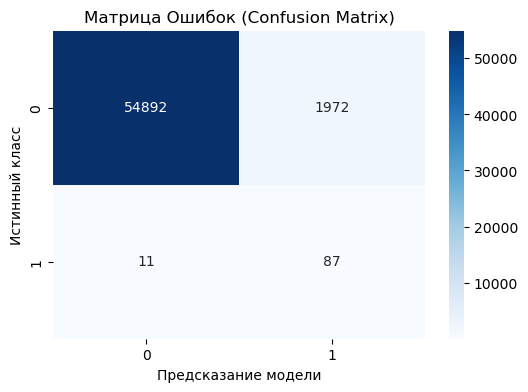

In [3]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Подготовка данных...")
# Отделяем фичи (X) и целевую переменную (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Разбиваем на train и test (стратификация важна, чтобы 492 фрода равномерно распределились)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Обучение алгоритма LightGBM...")
# Магия здесь: параметр is_unbalance=True заставляет модель обращать больше внимания на редкий класс!
model = lgb.LGBMClassifier(
    n_estimators=100,
    is_unbalance=True, # Включаем балансировку классов
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("3. Проверка модели на тестовых данных...")
y_pred = model.predict(X_test)

print("\n=== ОТЧЕТ О КИБЕРБЕЗОПАСНОСТИ ===")
print(classification_report(y_test, y_pred, target_names=['Нормальные (0)', 'Фрод (1)']))

print("\n4. Рисуем Матрицу Ошибок (Confusion Matrix)...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица Ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказание модели')
plt.show()